<a href="https://colab.research.google.com/github/jihye-jeon2/python/blob/main/Outlier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
#구글 드라이브 마운트
from google.colab import drive
drive.mount('/content/drive')

#드라이브에 저장된 폰트 등록
import matplotlib as mpl
import matplotlib.pyplot as plt  #그래프를그리는 pylpot모듈
import matplotlib.font_manager as fm #폰트를 관리하는 모듈

#드라이브내 폰트경로
font_path='/content/drive/MyDrive/kwu (1)/빅데이터/dataPreProcesing/NanumGothic.ttf'

fm.fontManager.addfont(font_path)
mpl.rc('font',family='NanumGothic') #matplotlib 기본 폰트로 설정
plt.rcParams['axes.unicode_minus'] = False #마이너스기호가 깨지지않도록 유니코드 마이너스 비활성화

print("현재폰트:  ",plt.rcParams['font.family'])  #현재 적용된 폰트 이름 출력'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
현재폰트:   ['NanumGothic']


In [4]:
import pandas as pd # 데이터프레임 조작
import numpy as np #수치 계산 및 NaN(결측치) 처리
import matplotlib.pyplot as plt #그래프 시각화
import seaborn as sns #시각화

#타이타닉 데이터로드
titanic = pd.read_csv('/content/drive/MyDrive/kwu (1)/빅데이터/dataPreProcesing/train.csv')
print(titanic.shape)
titanic.head()


(891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
#타이타닉 결측치 전처리
titanic_clean=titanic.copy()

titanic_clean=titanic_clean.drop(columns=['Cabin'])

#Age 결측치 처리
titanic_clean['Age']=titanic_clean.groupby(['Sex','Pclass'])['Age'].transform(
    lambda x:x.fillna(x.median())
)

#Embarked 결측치 처리
titanic_clean['Embarked']=titanic_clean['Embarked'].fillna(
    titanic_clean['Embarked'].mode()[0]
)
#최종 결측치 현황 확인
print("전처리후결측치: ")
print(titanic_clean.isnull().sum()[titanic_clean.isnull().sum()>0])

print(f"\n원본 shape: {titanic.shape}")
print("전처리후 shape:{titanic_clean.shape}")

전처리후결측치: 
Series([], dtype: int64)

원본 shape: (891, 12)
전처리후 shape:{titanic_clean.shape}


In [5]:
from scipy import stats  #통계연산모듈, Z-score계산,Q-Q Plot등에 사용

print(titanic[['Age','Fare']].describe())  #기술통계량 출력
#이상치 잇으면:평균>>중앙값(50%),최대값이 75%보다 극단적으로 큰 경우  이상치->평균과중앙값을 비교해본다

              Age        Fare
count  714.000000  891.000000
mean    29.699118   32.204208
std     14.526497   49.693429
min      0.420000    0.000000
25%     20.125000    7.910400
50%     28.000000   14.454200
75%     38.000000   31.000000
max     80.000000  512.329200


###실습1 시각화로 이상치 탐색

In [ ]:
fig.axes=plt.subplots(2,2,figsize=(12,8))#2행2열
fig.supitle('타이타닉 이상치 탐색 시각화', fontsize=14)

#fare박스플롯
axes[0,0].boxplot(titanic_clean['Fare'].dropna())
axes[0,0].set_title('fare박스플롯')
axes[0,0].set_ylable('운임($)')  #y

#fare히스토그램
axes[0,1].hist(titanic['Fare'],bins=50,color='steelblue',edgecolor='white')
axes=[0,1].set_title('fare 히스토그램')
axes=[0,1].set_xlable('운임($)')

#age박스플롯
axes[1,0].boxplot(titanic['Age'].dropna())
axes[1,0].set_title('age 박스플롯')
axes[1,0].set_ylable('나이')

#fare vs age산점도
axes[1,1].scatter(titanic['Age'],titanic['Fare'],alpha=0.3,color='coral')
axes[1,1].set_title('age vs fare 산점도')
axes[1,1].set_xlable('나이')
axes[1,1]

print.tight_layout()
plt.show()

print('운임상위10개')
print(titanic_clean['Fare'].

In [7]:
###실습2.IQR방법으로 이상치 탐지

In [14]:
#IQR(사분위 범위)계산
Q1 = titanic_clean['Fare'].quantile(0.25)  #quantile() 사분위구하는함수
Q3=titanic_clean['Fare'].quantile(0.75)
IQR = Q3-Q1

lower_bound=Q1 - 1.5* IQR  #하한선
upper_bound=Q3+1.5*IQR  #상한선    ...   #이상치 탐색

print(f"Q1: {Q1:.1f}")
print(f"Q3: {Q3:.1f}")
print(f"IQR: {IQR:.1f}")
print(f"정상범위:{lower_bound:.1f}~{upper_bound:.1f}")

#이상치 마스킹
outlier_mask=(titanic_clean['Fare']<lower_bound) | (titanic_clean['Fare']>upper_bound)  #| 이건 '또는'임 / 논리연산자bool 형으로 반환댐
outliers=titanic_clean[outlier_mask] #이상치 마스크가 True인 행만 추출

print("\n 이상치 승객 상위 5명")
print(outliers[['Pclass','Sex','Age','Fare','Survived']].head())

print(f"\n 이상치 개수: {outlier_mask.sum()} ")
print(f"전체 대비 비율: {outlier_mask.mean()*100:.1f}") #평균*100 비율구함



Q1: 7.9
Q3: 31.0
IQR: 23.1
정상범위:-26.7~65.6

 이상치 승객 상위 5명
    Pclass     Sex   Age      Fare  Survived
1        1  female  38.0   71.2833         1
27       1    male  19.0  263.0000         0
31       1  female  35.0  146.5208         1
34       1    male  28.0   82.1708         0
52       1  female  49.0   76.7292         1

 이상치 개수: 116 
전체 대비 비율: 13.0


###실습3. Z-score방법으로 이상치 탐지

In [20]:
#Z-score계산
fare_zscore=stats.zscore(titanic_clean['Fare'].dropna())#NaN제거 후 각 값의 Z-score계산

#|Z|>3인 값을 이상치로 판단
zscore_series=pd.Series(fare_zscore,index=titanic_clean['Fare'].dropna().index)
outlier_z_mask=zscore_series.abs()>3 #Z-score절대값이 3초과인행을 이상치로 표시

print(f"Z-score기준 이상치 수: {outlier_z_mask.sum()}")  #IQR이상치 탐색->16 / #Z-score이상치 탐색->20

#IQR vs Z-score 비교
fare_clean=titanic_clean[['Fare']].copy() #새 프레임 생성
fare_clean['z-score'] = zscore_series
fare_clean['is_outlier_iqr']=outlier_mask
fare_clean['is_outlier_z']=outlier_z_mask

print('\n 두 방법 비교')
print(f"IQR이상치:{outlier_mask.sum()}개")
print(f"Z-score 이상치: {outlier_z_mask.sum()}개")
print(f"두 방법 모두 이상치:{(outlier_mask & outlier_z_mask).sum()}")

Z-score기준 이상치 수: 20

 두 방법 비교
IQR이상치:116개
Z-score 이상치: 20개
두 방법 모두 이상치:20


###실습4 이상치 시각화 - 탐지 결과표시

In [23]:
fig.axes=plt.subplots(1,2,figsize=(13,5)) # 1행2열 서브플롯 생성

#공통색상 설정 : IQR상한 초과면 빨강,정상이면 파랑
colors=titanic_clean['Fare'].apply(
    lambda x: 'red' if x>upper_bound else 'blue'
)
#이상치 강조 산점도
axes[0].scatter(range(len(titanic_clean)), titanic_clean['Fare'], c=colors, alpha=0.5,s=20)   #scatter(x축,y축) (승객,요금) alpha투명도 s는 점크기 지정
axes[0].axhile(y=upper_bound, color='red',linestyle='--', label=f"IQR상한:{upper_bound:.1f}")#이선위에 상한선을 나타낸다(?)
axes[0].set_title('fare이상치 탐지(IQR방법)')
axes[0].set_xlable('승객 인덱스')
axes[0].set_ylable('운임($)')
axes[0].legend()

#등급별 박스플롯(그룹비교)
titanic_clean.boxplot(column='Fare',by='Pclass',ax=axas[1]) #객실요금의 값을 박스플롯으로보겟다라는거래
axes[1].set_title('등급별 운임 분포')
axes[1].set_xlable('객실등급')
axes[1].set_ylable('운임($)')

plt.suptitle('')  #공백/상단제목을 빈 문자열
plt.tight_layout()
plt.show()

AttributeError: Figure.set() got an unexpected keyword argument 'figaxes'

###실습5 이상치 처리 -제거(Drop)

In [30]:
#이상치 제거
titanic_no_outlier=titanic[~outlier_mask].copy() #~은 not연산자 즉 이상치가 아님,정상치

print(f"원본 행 수: {len(titanic_clean)}")
print(f"이상치 제거 후: {len(titanic_no_outlier)}")

#제거 전후 fare통계비교
comparison=pd.DataFrame({
    '원본':titanic_clean['Fare'].describe(),
    '이상치제거후':titanic_no_outlier['Fare'].describe()
}).round(2)
display(comparison)

원본 행 수: 891
이상치 제거 후: 775


,원본,이상치제거후
count,891.00,775.00
mean,32.20,17.82
std,49.69,13.58
min,0.00,0.00
25%,7.91,7.90
50%,14.45,13.00
75%,31.00,26.00
max,512.33,65.00


###실습6 이상치 처리-캡핑(Clipping)

In [31]:
#이상치를 제거하지 않고 경계값으로 대체 , 데이터수(891행)유지
titanic_clipped=titanic_clean.copy()
titanic_clipped['Fare_clipped'] = titanic_clipped['Fare'].clip(
    lower=max(lower_bound,0)  #lower_bound 값인 -26.7과 0중 Max 택
)#clip():범위 밖의 값을 경계값으로 강제 변환  요금 중에 음수는 없으니까

#결과확인
print('캡핑 전 최대값:',titanic_clean['Fare'].max())
print('캡핑 후 최대값: ',titanic_clipped['Fare_clipped'].max())
print('행수변화없음: ',len(titanic_clipped))

#전후비교 박스플롯
fig.axes=plt.subplots(1,2,figsize=(10,4))
axes[0].boxplot(titanic_clean['Fare'])
axes[0].set_title('원본 fare')
axes[1].boxplot(titanic_clipped['Fare_clipped'])
axes[1].set_title('캡핑 후 fare')

plt.suptitle('이상치 캡핑 전후 비교')

캡핑 전 최대값: 512.3292
캡핑 후 최대값:  512.3292
행수변화없음:  891


###정규분포 확인방법


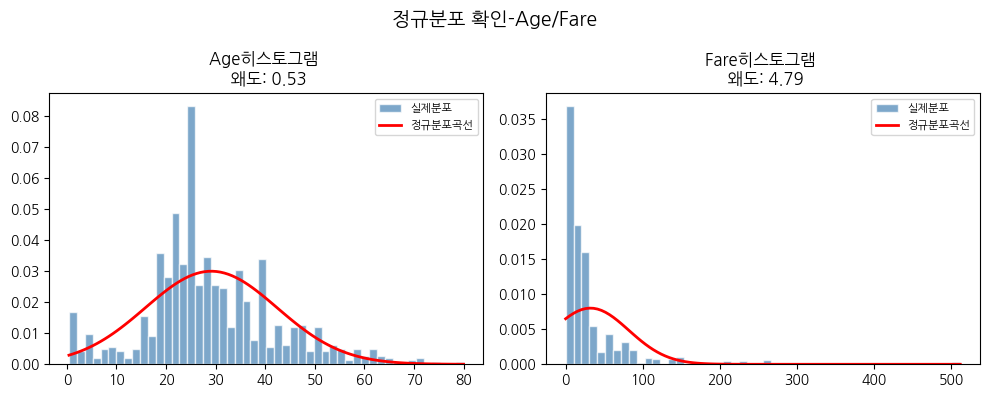

In [35]:
#정규분포 확인을 위한 시각화
fig,axes=plt.subplots(1,2,figsize=(10,4))
fig.suptitle('정규분포 확인-Age/Fare',fontsize=14)

cols=['Age','Fare']

for i,col in enumerate(cols):
  data=titanic_clean[col].dropna()
  # 히스토그램 + 정규분포곡선
  ax1=axes[i]  #density=True로 y축을 밀도(확률)로 변환해 정규분포 곡선과 겹쳐 비교 가능
  ax1.hist(data,bins=50,density=True,color='steelblue',edgecolor='white',alpha=0.7,label='실제분포')

  #정규분포 곡선 그리기
  x=np.linspace(data.min(), data.max(),100)#데이터 최소-최대 범위에서 100개 균등 간격 x값 생성
  ax1.plot(x,stats.norm.pdf(x,data.mean(),data.std()),color='red',linewidth=2,label='정규분포곡선')
  ax1.set_title(f'{col}히스토그램 \n 왜도: {data.skew():.2f}')#왜도가 -1~1사이면 정규분포에 가까움 , 왜도->그래프가 얼마나 한쪽으로 쏠렷는지. 0에 가까울수록 정규분포모양
  ax1.legend(fontsize=8)
plt.tight_layout()
plt.show()

###실습7. 이상치 처리-로그변환(젤 중요하대)
*np.log1p()는 log(1+x)를 계산해주는 넘파이(Numpy)함수<br>
*데이터가 한쪽으로 크게 치우쳐잇을때(양의왜도)   이를 정규분포형태로 변환하기 위해 사용<br>
*모든데이터에 1을더한후 로그를 취하면 0이엇던데이터는 log(1)=0이되어 안전하게 변환<br>
*1p는 plus 1 을의미<br>
(왜 ?? x=0 x>0 운임 0은 ok /log 0은 정의불가능)<br>
*값이 너무 큰 데이터(이상치)의 수치를 압축

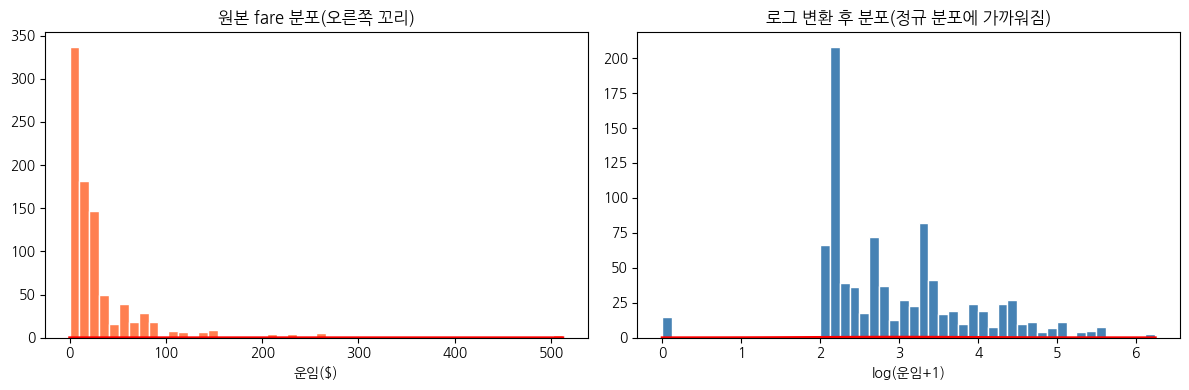

원본 fare왜도: 4.79
로그변환 후 왜도: 0.39


In [45]:
#로그 변환(Fare히스토그램 왜도skew()함수를사용/ 가 큼, 이상치때매 ->로그변환)
#오른쪽으로 긴 꼬리(right-skewd)분포를 로그 변환으로 정규분포에 가깝게 변환
titanic_log=titanic_clean.copy()
#log(0)은 정의불가, x=0일때도 log1로 안전하게 처리하게위함 / 1p
titanic_log['Fare_log']=np.log1p(titanic_clean['Fare'])#1p , 각 운임값에 log(1+x) 변환 적용

fig,axes=plt.subplots(1,2,figsize=(12,4))

axes[0].hist(titanic_clean['Fare'],bins=50,color='coral',edgecolor='white')
x=np.linspace(titanic_clean['Fare'].min(),titanic_clean['Fare'].max(),100)
axes[0].plot(x,stats.norm.pdf(x,titanic_clean['Fare'].mean(),titanic_clean['Fare'].std()),color='red',linewidth=2)
axes[0].set_title('원본 fare 분포(오른쪽 꼬리)')
axes[0].set_xlabel('운임($)')

axes[1].hist(titanic_log['Fare_log'],bins=50,color='steelblue',edgecolor='white')
x=np.linspace(titanic_log['Fare_log'].min(),titanic_log['Fare_log'].max(),100)
axes[1].plot(x,stats.norm.pdf(x,titanic_log['Fare_log'].mean(),titanic_log['Fare_log'].std()),color='red',linewidth=2)
axes[1].set_title('로그 변환 후 분포(정규 분포에 가까워짐)')
axes[1].set_xlabel('log(운임+1)')

plt.tight_layout()
plt.show()

#왜도(skewness)비교: 왜도가 0에 가까울수록 대칭적(정규분포에 가까움)
print(f"원본 fare왜도: {titanic_clean['Fare'].skew():.2f}")
print(f"로그변환 후 왜도: {titanic_log['Fare_log'].skew():.2f}")


###실습8 다변수 이상치 탐지(나이+운임)  /혼자선ㄱㅊ은데 조합하면 이상치로가는애들이잇다 / 변수들을 결합할일이 많음

다변수이상치:5개
       Age      Fare     Age_z    Fare_z
195  58.00  146.5208  2.172495  2.301729
268  58.00  153.4625  2.172495  2.441498
297   2.00  151.5500 -2.038995  2.402990
305   0.92  151.5500 -2.120216  2.402990
438  64.00  263.0000  2.623727  4.647001


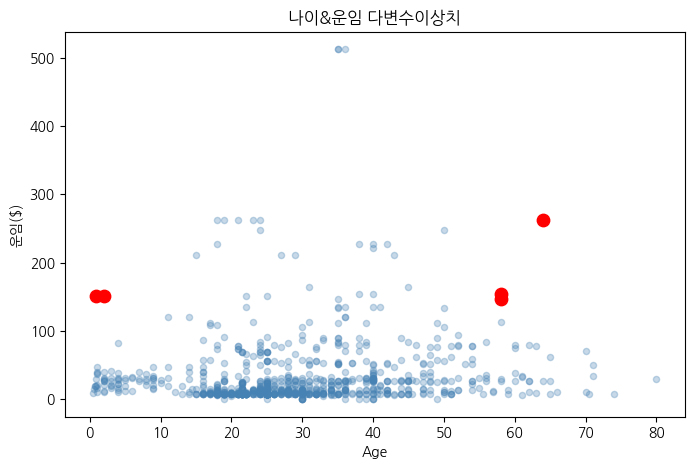

In [51]:
#다변수 이상치 탐지: 단일 변수로는 정상이지만 조합이 이상한 경우
#예: 나이 1살인데 운임 500달러 -> Age단독 ok,Fare단독 OK, 하지만 조합이 이상함

titanic_bivar=titanic_clean[['Age','Fare']].dropna().copy()

#두변수에 각각 Z-score적용
titanic_bivar['Age_z']= stats.zscore(titanic_bivar['Age'])
titanic_bivar['Fare_z'] = stats.zscore(titanic_bivar['Fare'])

#두변수모두 |Z| >2다변수 이상치로 판단
both_extreme=(titanic_bivar['Age_z'].abs()>2)&(titanic_bivar['Fare_z'].abs()>2)

print(f"다변수이상치:{both_extreme.sum()}개")
print(titanic_bivar[both_extreme]) #True에 해당하는 행 출력

#산점도로 다변수 이상치 시각화
plt.figure(figsize=(8,5))
normal=~both_extreme
plt.scatter(titanic_bivar.loc[normal,'Age'],
            titanic_bivar.loc[normal,'Fare'],
            alpha=0.3,color='steelblue',label='정상',s=20)
plt.scatter(titanic_bivar.loc[both_extreme,'Age'],
            titanic_bivar.loc[both_extreme,'Fare'],
            color='red',label='다변수이상치',s=80,zorder=5)#zorder=5 정상 점보다 위에 그려짐

plt.xlabel('Age')
plt.ylabel('운임($)')
plt.title('나이&운임 다변수이상치')
plt.show()



###실습9.종합-처리방법별결과비교


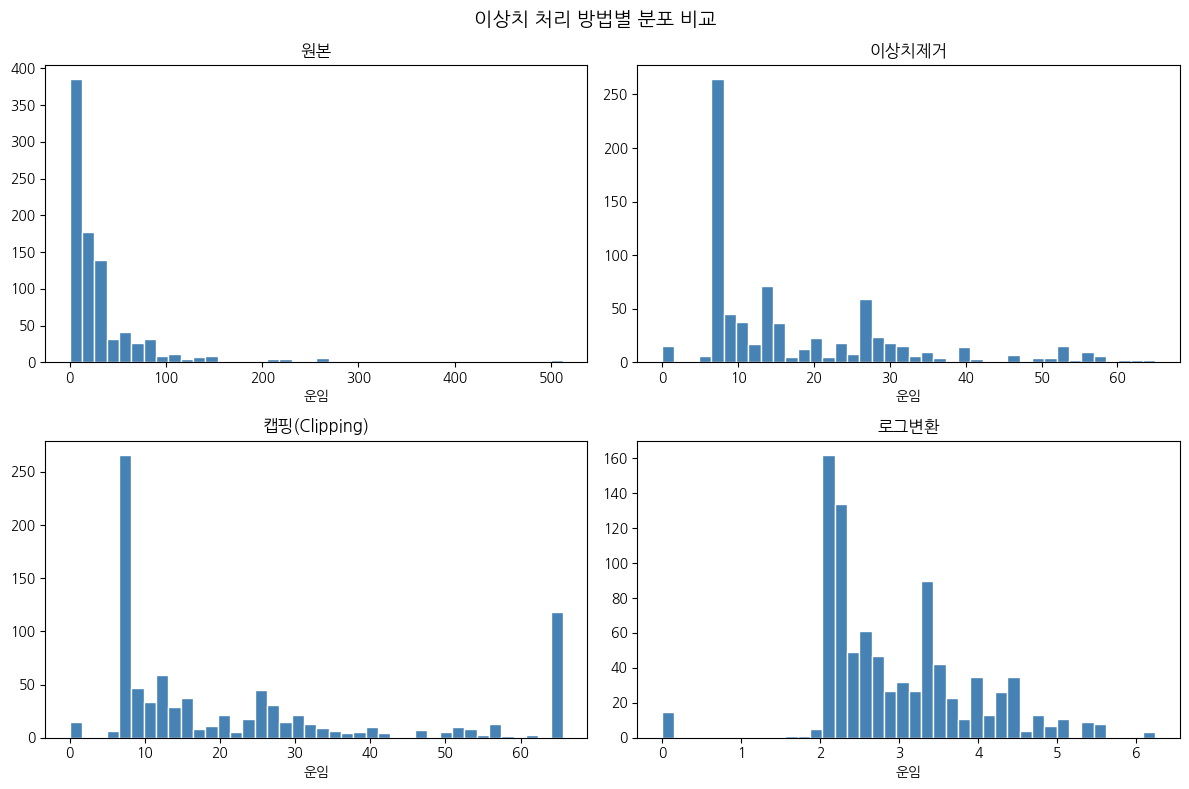

,원본,제거,캡핑,로그변환
count,891.00,775.00,891.00,891.00
mean,32.20,17.82,24.05,2.96
std,49.69,13.58,20.48,0.97
min,0.00,0.00,0.00,0.00
25%,7.91,7.90,7.91,2.19
50%,14.45,13.00,14.45,2.74
75%,31.00,26.00,31.00,3.47
max,512.33,65.00,65.63,6.24


In [55]:
#이상치 처리 4가지 방법을 한눈에 비교
fare_original=titanic_clean['Fare']

#방법2: 이상치 제거(행수줄어듬)
fare_dropped=titanic_clean.loc[~outlier_mask,'Fare'] #정상데이터만 선택 (~ not)

#방법3 캡핑(이상치를 상한값으로 교체,행수 유지)
fare_clipped=titanic_clean['Fare'].clip(upper=upper_bound) #상한을 초과한 값을상한값으로 대체하

#방법4 로그변환(분포형태자체를 변환 ~ 정규분포와비슷하게)
fare_log = np.log1p(titanic_clean['Fare']) #log(1+x)변환으로 오른쪽 꼬리 분포를 정규분포에 가깝게 변환

fig,axes=plt.subplots(2,2 ,figsize=(12,8))  #2행2열 ->2차원배열
fig.suptitle('이상치 처리 방법별 분포 비교',fontsize=14)

for ax, data ,title in zip(
    axes.flatten(), #2D배역을 1D로 펼쳐 순서대로 순회 axes[0,1]->axes[0,1,2,3]
    [fare_original, fare_dropped, fare_clipped, fare_log],['원본','이상치제거','캡핑(Clipping)','로그변환']
):

  ax.hist(data,bins=40,edgecolor='white',color='steelblue')
  ax.set_title(title)
  ax.set_xlabel('운임')

plt.tight_layout()
plt.show()

#방법별 요약 통계 비교표
summary=pd.DataFrame({
    '원본': fare_original.describe(),
    '제거': fare_dropped.describe(),
    '캡핑': fare_clipped.describe(),
    '로그변환': fare_log.describe()
}).round(2)
display(summary)
